# MLP — Solving What Perceptron Could Not

Last session we saw that a **single perceptron** cannot solve XOR.
It can only draw **one straight line** — and XOR needs two.

```
Perceptron:   input → [node] → output          (1 line)
MLP:          input → [hidden layer] → [output] (2+ lines)
```

Today we add a **hidden layer** — and watch XOR get solved.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense

# XOR dataset — the problem the perceptron could NOT solve
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])

print("XOR dataset:")
for x, y in zip(X_xor, y_xor):
    print(f"  {x} → {y}")


XOR dataset:
  [0 0] → 0
  [0 1] → 1
  [1 0] → 1
  [1 1] → 0


## Why Perceptron Failed

The perceptron draws **one straight line**.
XOR points look like this — no single line can separate them:

```
  (0,1)=1    (1,1)=0
      ●          ○

      ○          ●
  (0,0)=0    (1,0)=1
```

## The Fix — Add a Hidden Layer

```
Perceptron:   x1, x2  →  [1 node]             →  output
MLP:          x1, x2  →  [hidden: 4 nodes]    →  [1 node]  →  output
```

The hidden layer learns **intermediate features** — combinations of x1 and x2
that make XOR linearly separable for the output node.


## Build the MLP


In [2]:
tf.random.set_seed(42)

# Step 1: create the empty model
model = keras.Sequential()

# Step 2: hidden layer — 4 nodes, ReLU activation
# ReLU: if sum < 0 → output 0, else → output the sum
model.add(Dense(5, activation="relu", input_shape=(2,)))

# Step 3: output layer — 1 node, sigmoid (same as perceptron)
model.add(Dense(1, activation="sigmoid"))

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the MLP


In [3]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_xor, y_xor, epochs=500, verbose=1)
preds = (model.predict(X_xor, verbose=0) >= 0.5).astype(int).flatten()

print("MLP Predictions:", preds)
print("Expected:        [0 1 1 0]")
print("Solved!") if list(preds) == [0,1,1,0] else print("Not solved yet — try more epochs")


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step - accuracy: 0.5000 - loss: 0.7393
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2500 - loss: 0.7334
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2500 - loss: 0.7278
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2500 - loss: 0.7223
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2500 - loss: 0.7171
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2500 - loss: 0.7120
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2500 - loss: 0.7070
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 0.7020
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6972
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7500 - loss: 0.6930
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.6888
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - l

## Loss Curve


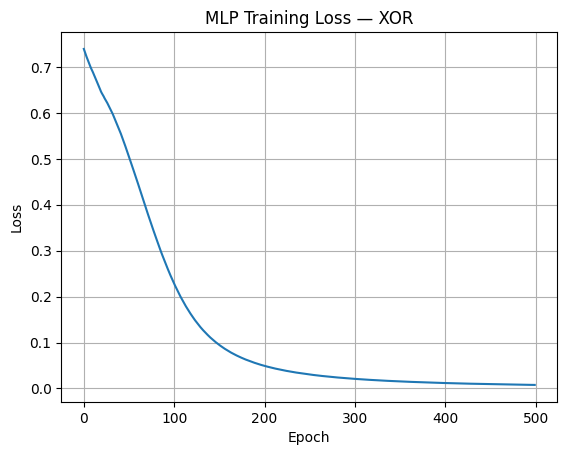

In [4]:
plt.plot(history.history['loss'])
plt.title("MLP Training Loss — XOR")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


## Decision Boundary

Unlike the perceptron (one straight line), the MLP draws a **curved/complex boundary**.


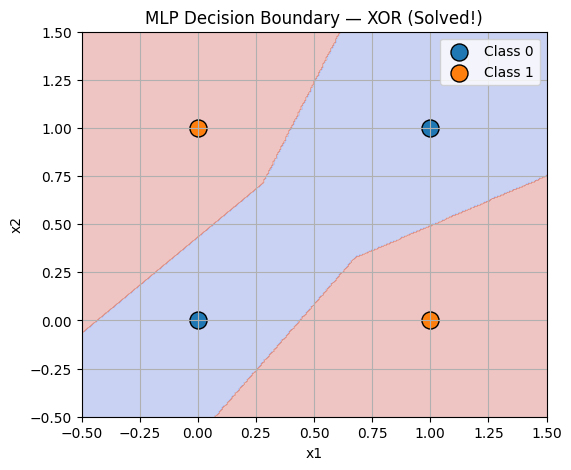

In [5]:
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = (model.predict(grid, verbose=0) >= 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

for label in [0, 1]:
    pts = X_xor[y_xor == label]
    plt.scatter(pts[:,0], pts[:,1], s=150, edgecolor='black', label=f"Class {label}")

plt.title("MLP Decision Boundary — XOR (Solved!)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


## Perceptron vs MLP

| | Perceptron | MLP |
|---|---|---|
| Layers | 1 (input → output) | 2+ (input → hidden → output) |
| Decision boundary | Straight line | Curved / complex |
| Solves XOR | No | Yes |
| Parameters | 3 (w1, w2, bias) | Many more |
| Can learn | Only linear patterns | Non-linear patterns |

**The hidden layer is the key.** It transforms the input into a new space where the problem becomes linearly separable.
